In [1]:
# show per sample the size of the explanation and the abstract explanation
# have another sign when cardinality bound is not effective

# bar plot with in average remaining sample

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
def get_ndim(DATASET):

    if DATASET.upper()=='GTSRB':
        return 1024
    else:
        return 784

def get_color(DATASET, MODEL):

    if DATASET.upper()=='GTSRB':
        if MODEL.lower()=='10x2':
            return 'green'
        else:
            return 'red'
    if DATASET.upper()=='MNIST':
        if MODEL.lower()=='10x2':
            return 'blue'
        else:
            return 'orange'
    raise ValueError('unknown combination')

# SIZE

In [23]:
def get_plot_size(DATASET, MODEL):

    n_dim = get_ndim(DATASET)
    color = get_color(DATASET, MODEL)
    
    verix_path = './results/final_version/VERIX/{}_{}_verix.csv'.format(DATASET.lower(), MODEL.lower())
    fame_path = './results/final_version/A_2/{}_{}_A_2.csv'.format(DATASET.upper(), MODEL.upper())
    abstract_domain_path = './results/final_version/A_1/{}_{}_A_1.csv'.format(DATASET.upper(), MODEL.upper())

    # Load CSVs
    verix = pd.read_csv(verix_path)
    fame = pd.read_csv(fame_path)
    abstract = pd.read_csv(abstract_domain_path)

    # Create new dataframe
    result = abstract[["index"]].copy()
    result["cardinality"] = abstract["greedy_size"] > 0

    # Merge on 'index'
    merged = pd.merge(verix, fame, on="index")
    merged = pd.merge(merged, result, on="index")
    # Compute y = n_dim - greedy_size
    merged["fame_time"] = n_dim - merged["greedy_time"]

    # Plot where cardinality is True
    true_points = merged[merged["cardinality"] == True]
    plt.scatter(true_points["size"], true_points["fame_size"],
            alpha=0.7, label="Cardinality = True", marker="o", color='tab:{}'.format(color))

    # Plot where cardinality is False
    false_points = merged[merged["cardinality"] == False]
    plt.scatter(false_points["size"], false_points["fame_size"],
            alpha=0.7, label="Cardinality = False", marker="s", color='tab:{}'.format(color))

    

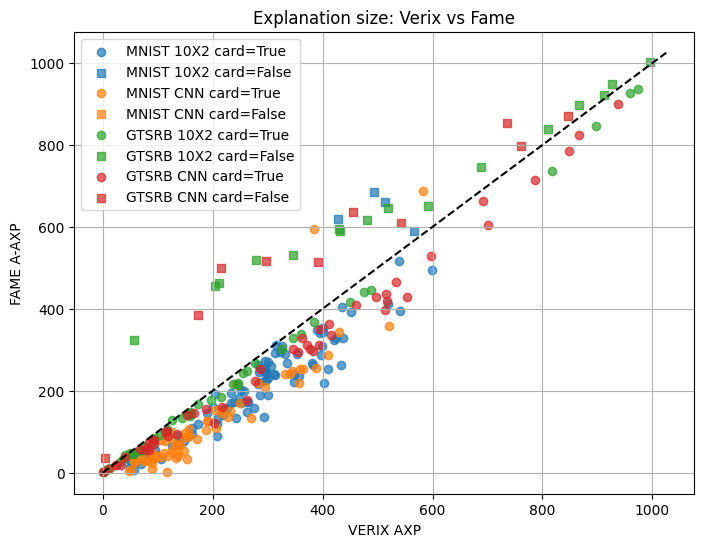

<Figure size 640x480 with 0 Axes>

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

legends=[]
for dataset in ['mnist', 'gtsrb']:
    for model in ['10x2', 'cnn']:
        get_plot(dataset, model)
        legends+=['{} {} card=True'.format(dataset.upper(), model.upper()), '{} {} card=False'.format(dataset.upper(), model.upper())]

# Add identity line y = x
min_val = 0
max_val = 1025
plt.plot([min_val, max_val], [min_val, max_val], "k--", label="y = x")

# Labels and title
plt.xlabel("VERIX AXP")
plt.ylabel("FAME A-AXP")
plt.title("Explanation size: Verix vs Fame")

plt.legend(legends)
plt.grid(True)
plt.show()   
plt.savefig('fame_vs_verix_size.png')

# TIME

In [26]:
def get_plot_time(DATASET, MODEL):

    n_dim = get_ndim(DATASET)
    color = get_color(DATASET, MODEL)
    
    verix_path = './results/final_version/VERIX/{}_{}_verix.csv'.format(DATASET.lower(), MODEL.lower())
    fame_path = './results/final_version/A_2/{}_{}_A_2.csv'.format(DATASET.upper(), MODEL.upper())
    abstract_domain_path = './results/final_version/A_1/{}_{}_A_1.csv'.format(DATASET.upper(), MODEL.upper())

    # Load CSVs
    verix = pd.read_csv(verix_path)
    fame = pd.read_csv(fame_path)
    abstract = pd.read_csv(abstract_domain_path)

    # Create new dataframe
    result = abstract[["index"]].copy()
    result["cardinality"] = abstract["greedy_size"] > 0

    # Merge on 'index'
    merged = pd.merge(verix, fame, on="index")
    merged = pd.merge(merged, result, on="index")
    # Compute y = n_dim - greedy_size
    merged["fame_time"] = merged["greedy_time"]

    # Plot where cardinality is True
    true_points = merged[merged["cardinality"] == True]
    plt.scatter(true_points["time"], true_points["fame_time"],
            alpha=0.7, label="Cardinality = True", marker="o", color='tab:{}'.format(color))

    # Plot where cardinality is False
    false_points = merged[merged["cardinality"] == False]
    plt.scatter(false_points["time"], false_points["fame_time"],
            alpha=0.7, label="Cardinality = False", marker="s", color='tab:{}'.format(color))

    

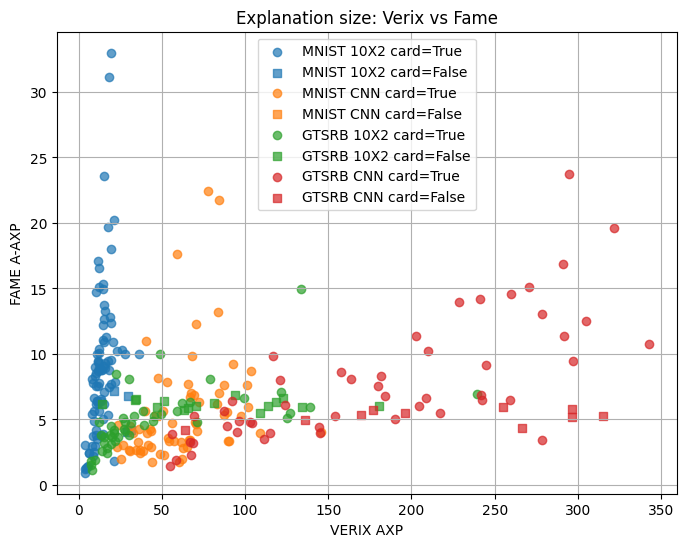

<Figure size 640x480 with 0 Axes>

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

legends=[]
for dataset in ['mnist', 'gtsrb']:
    for model in ['10x2', 'cnn']:
        get_plot_time(dataset, model)
        legends+=['{} {} card=True'.format(dataset.upper(), model.upper()), '{} {} card=False'.format(dataset.upper(), model.upper())]

# Add identity line y = x
min_val = 0
max_val = 360

# Labels and title
plt.xlabel("VERIX AXP")
plt.ylabel("FAME A-AXP")
plt.title("Explanation size: Verix vs Fame")

plt.legend(legends)
plt.grid(True)
plt.show()   
plt.savefig('fame_vs_verix_time.png')

In [29]:
pwd

'/Users/ducoffe_m/Documents/Code/object_detection/local_installation/FAME/notebooks'